# Train and Tune Convolutional Neural Network Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.cnn import CNNModel
from src.models.factory import Experiment
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, plot_return_overlay
from src.runners import run_experiments
from src.utils import results_to_df, set_seed

In [2]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.n_trials_nn
SPLITS = cfg.runtime.n_splits
TRAIN_RATIO = cfg.runtime.train_ratio
VAL_RATIO = cfg.runtime.val_ratio
GAP = cfg.runtime.gap
SUBSAMPLE_TRAIN = cfg.runtime.subsample_train
N_JOBS = cfg.runtime.n_jobs
rng = set_seed(SEED)

2025-09-13 16:24:54,065 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "cnn"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed, n_jobs: CNNModel(horizon=HORIZON, random_state=SEED, n_jobs=n_jobs),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(
    df=df_full,
    out_dir=Path(cfg.data.processed_dir),
    experiments=experiments,
    forecast_horizon=HORIZON,
    random_state=SEED,
    n_trials=TRIALS,
    n_splits=SPLITS,
    gap=GAP,
    subsample_train=SUBSAMPLE_TRAIN,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    n_jobs=N_JOBS
)

2025-09-13 16:24:54,105 - INFO - src.utils - Global random seed set to 42
2025-09-13 16:24:54,124 - INFO - ModelTrainer - Initialized trainer for cnn
2025-09-13 16:26:36,894 - INFO - ModelTrainer - Initialized trainer for cnn
2025-09-13 16:26:37,847 - INFO - ModelTrainer - Evaluating model...


In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, horizon=HORIZON)

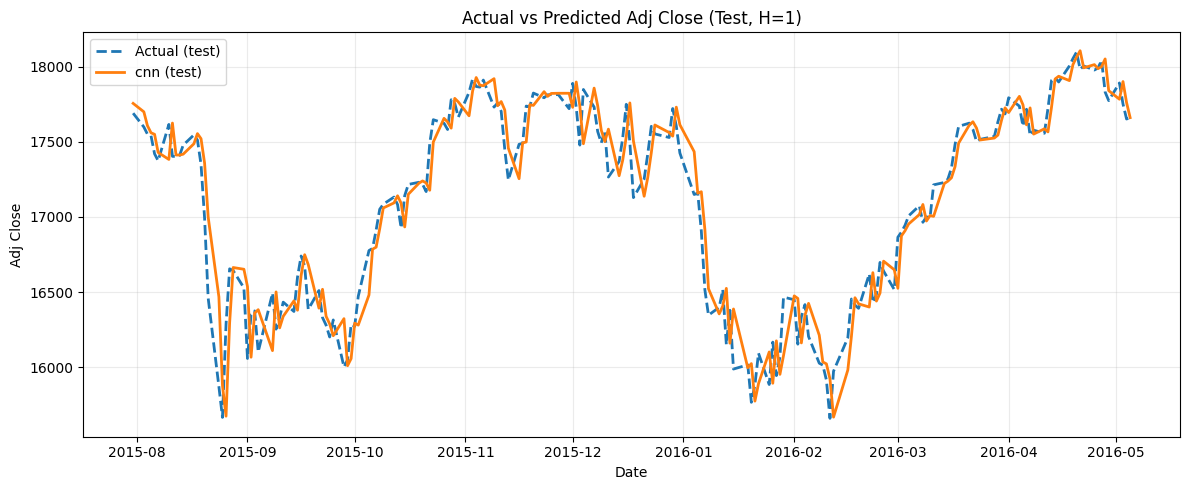

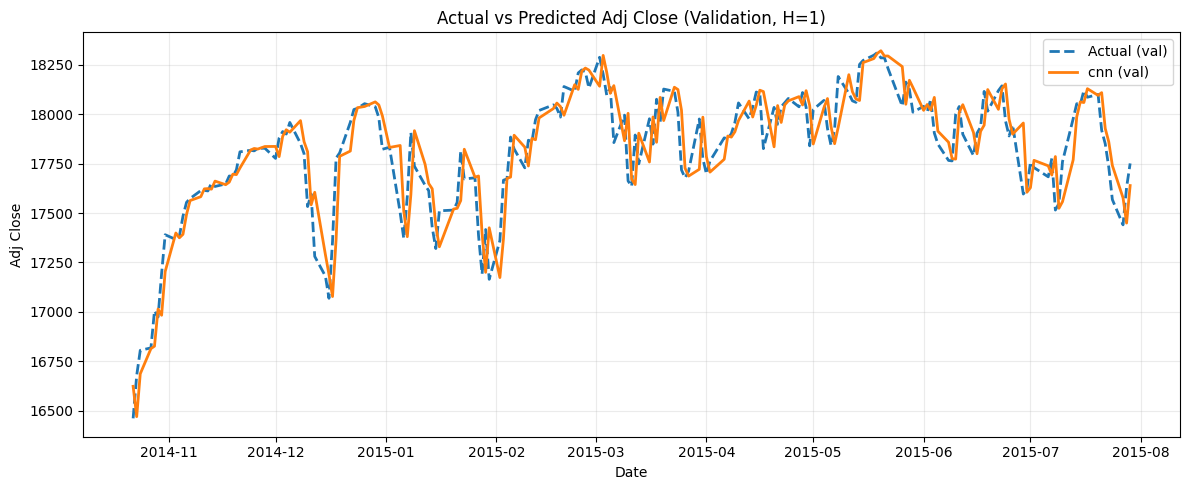

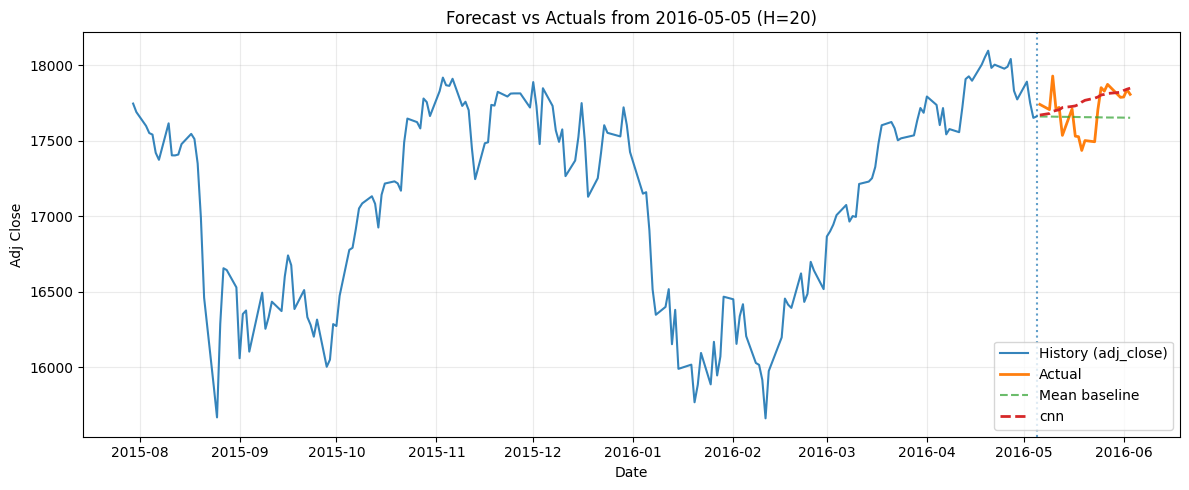

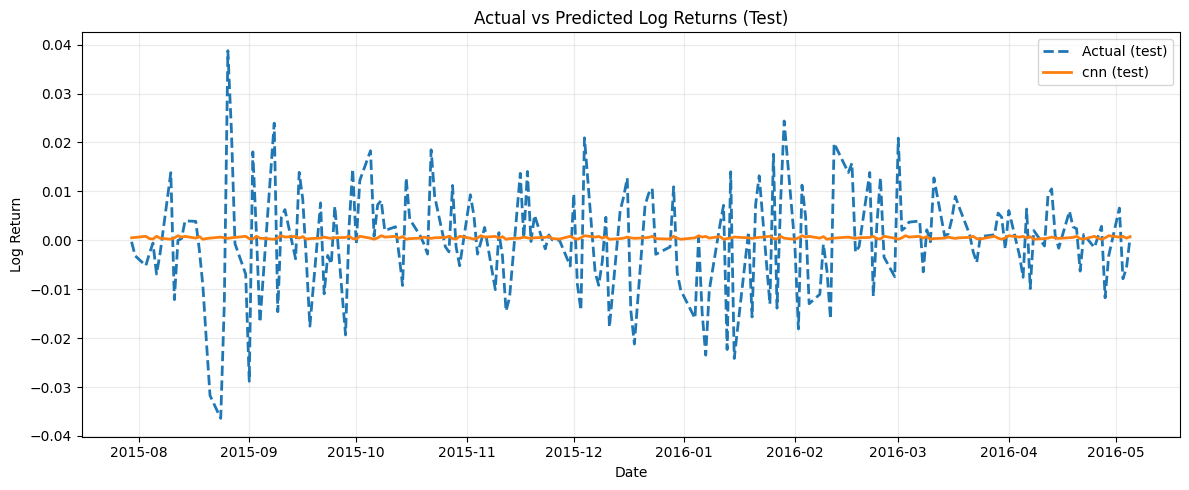

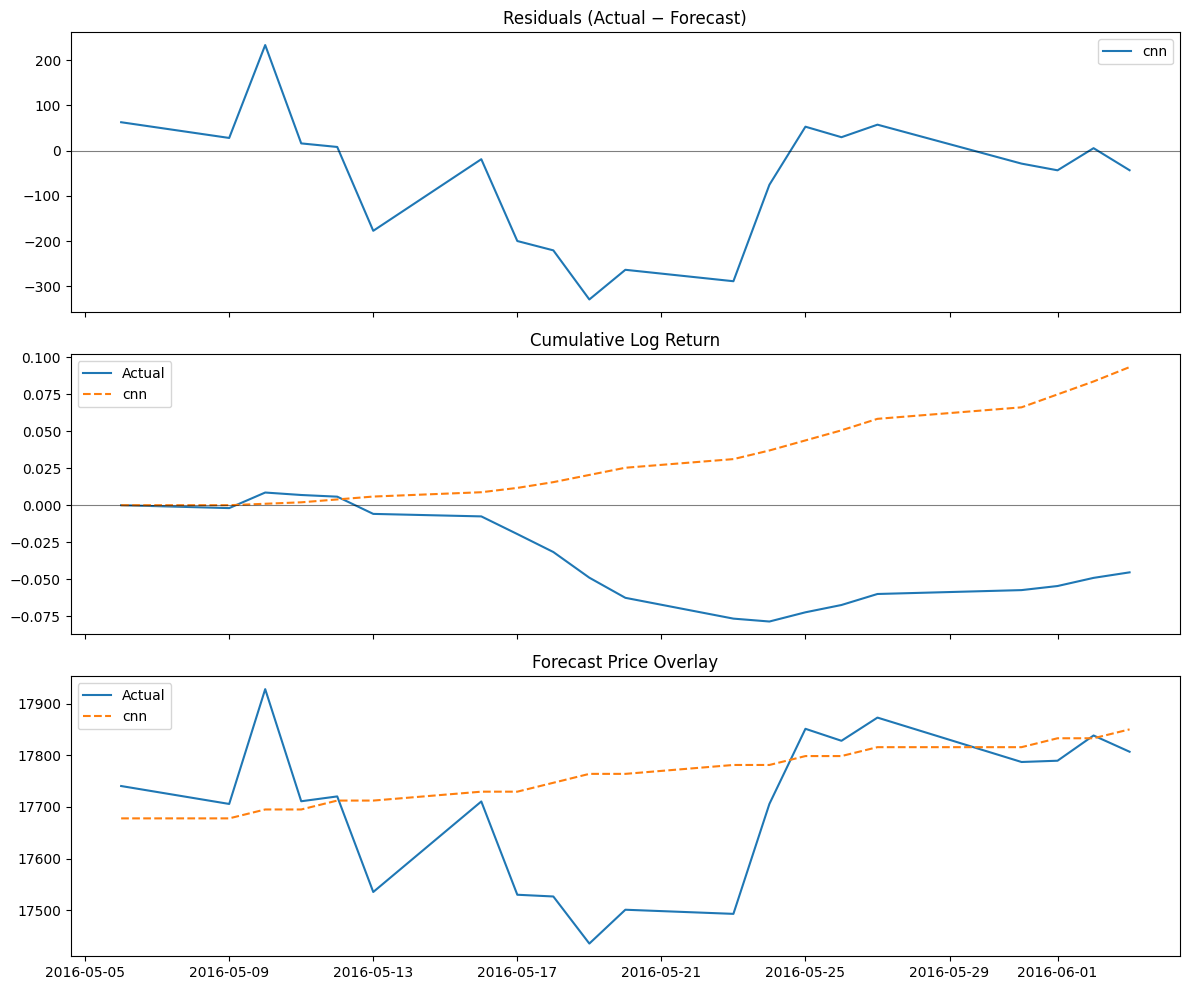

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_test.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_returns.png", "test")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,filters,kernel_size,dense_units,dropout,lr,epochs,batch_size,weight_decay,random_state
0,cnn,8,4,48,0.107143,0.002557,40,32,0.000007,42


In [9]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,cnn,0.008158,0.000118,0.010841,-0.001668,0.529016


In [10]:
metrics_summary = results_to_df(results, ["metrics", "test", "per_horizon"])
metrics_summary = metrics_summary[metrics_summary["model"] == MODEL_NAME]
metrics_summary

,model,per_horizon,mae,mse,rmse,r2,directional_accuracy
0,cnn,1,0.008169,0.000119,0.010924,-0.002243,0.518135
1,cnn,2,0.008163,0.000119,0.010926,-0.002813,0.518135
2,cnn,3,0.008198,0.000120,0.010964,-0.004270,0.523316
3,cnn,4,0.008246,0.000121,0.010978,-0.000706,0.523316
4,cnn,5,0.008245,0.000120,0.010976,-0.000345,0.528497
5,cnn,6,0.008260,0.000121,0.011017,-0.005098,0.528497
6,cnn,7,0.008292,0.000121,0.011015,-0.000906,0.533679
7,cnn,8,0.008285,0.000121,0.010993,-0.000423,0.528497
8,cnn,9,0.008215,0.000120,0.010965,-0.001724,0.528497
9,cnn,10,0.008251,0.000121,0.011001,-0.007093,0.528497


In [11]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()